In [219]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [220]:
df = pd.read_csv('housing_data_after_univariate_eda.csv').drop(columns={'Unnamed: 0'})

#`Key Findings From EDA`

1. The key price driving factors are beds, baths, sqft, price_per_sqft, estimated_monthly_payment, property_type, region , zip_code

2. The key price non driving cols : sqft_lot_cleaned, year_build (never expected : - ] , walk_score, bike_score, all school distances )

3. Parking space and estimated monthly payment is slightly correlated to beds, baths and sqft

In [221]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'sqft_lot', 'address',
       'estimated_monthly_payment', 'property_type', 'price_per_sqft',
       'year_built', 'region', 'interior_features', 'other_rooms',
       'appliances', 'utilities_Electric', 'utilities_Sewer',
       'utilities_Water', 'utilities_Utilities', 'parking_total_spaces',
       'parking_parking_features', 'walk_score', 'bike_score', 'transit_score',
       'elementary_school_name', 'elementary_school_distance',
       'middle_school_name', 'middle_school_distance', 'high_school_name',
       'high_school_distance', 'flood_risk', 'fire_risk', 'wind_risk',
       'air_risk', 'heat_risk', 'nearby_cities', 'property_history',
       'parking_uncovered_spaces', 'parking_garage_spaces', 'price',
       'sqft_lot_caterogy', 'sqft_lot_cleaned', 'zip_code'],
      dtype='object')

In [222]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,42,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,45,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,32,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,42,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,52,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474


# Feature Engineering

Idea to implement / Try (there might be few of the changes that are not making any progress. so i wont be continuing with those )for each col:

1. House Age -> current year - year_built
2.

#`property_age`

In [223]:
df['year_built'].unique()

array([1880., 1952., 1926., 1908., 1912., 2025., 1945., 1923., 1965.,
       2013., 2007., 1920., 1930., 1985., 1962., 1989., 1929., 1922.,
       1850., 1906., 1971., 1870., 1910., 1925., 1900., 1991., 2016.,
       1975., 1915., 1973., 1960., 2003., 1990., 1978., 1998., 1955.,
       1942., 1948., 1961., 1949., 1987., 1974., 1984., 2010., 1972.,
       2017., 2002., 1995., 1983., 1958., 2006., 2005., 1957., 1921.,
       2018., 1888., 1918., 1911., 1970., 1986., 1939., 1878., 1940.,
       1874., 1966., 1946., 2001., 1981., 1956., 2004., 1967., 1993.,
       1924., 1954., 1979., 1950., 1963., 1999., 1830., 1887., 1996.,
       1736., 2014., 1916., 1997., 1890., 1951., 1868., 2024., 1904.,
       1968., 1901., 1810., 1994., 1964., 1969., 2019., 1725., 2009.,
       1992., 1988., 1897., 2023., 1980., 2000., 1875., 1976., 1770.,
       1905., 1977., 2008., 2012., 1773., 1959., 1895., 1860., 1720.,
       1913., 1800., 1831., 1937., 1750., 1938., 2022., 1854., 1935.,
       1941., 1953.,

In [224]:
temp = (2025 - df['year_built'].astype('float')).sort_values(ascending=False)

In [225]:
for i in temp:
  if i < 0:
    print(i)

-1.0
-1.0
-1.0
-1.0
-891.0
-7974.0


In [226]:
df['property_age'] = (2025 - df['year_built'].astype('float'))

In [227]:
df[df['property_age'] == -7974.0] # 1970 built year

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
2490,https://www.zillow.com/homedetails/1515-Vfw-Pk...,https://photos.zillowstatic.com/fp/ece6c47106f...,2,1,500,"1,100 sqft","1515 Vfw Pkwy #M19, West Roxbury, MA 02132",NaN,condo,300,9999,West Roxbury,fireplace,den; basement; office,range; refrigerator; oven,NaN,public sewer,public,NaN,1,NaN,70,51,NaN,Nearby,NaN,Nearby,NaN,It is,1,6,1,6,2,6,Boston; Chelsea; Revere; Winthrop,"{'date': '3/27/2024', 'event': 'Listing remove...",NaN,NaN,150000,Ultra Compact,1,2132,-7974


In [228]:
df.loc[2490, 'year_built'] = '1970'

/tmp/ipython-input-2488253642.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1970' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[2490, 'year_built'] = '1970'


In [229]:
df[df['property_age'] == -7974.0] # confirming

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
2490,https://www.zillow.com/homedetails/1515-Vfw-Pk...,https://photos.zillowstatic.com/fp/ece6c47106f...,2,1,500,"1,100 sqft","1515 Vfw Pkwy #M19, West Roxbury, MA 02132",NaN,condo,300,1970,West Roxbury,fireplace,den; basement; office,range; refrigerator; oven,NaN,public sewer,public,NaN,1,NaN,70,51,NaN,Nearby,NaN,Nearby,NaN,It is,1,6,1,6,2,6,Boston; Chelsea; Revere; Winthrop,"{'date': '3/27/2024', 'event': 'Listing remove...",NaN,NaN,150000,Ultra Compact,1,2132,-7974


In [230]:
df[df['property_age'] == -891.0] # the year_built is 2016 on the website

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
1984,https://www.zillow.com/homedetails/5-Brigham-S...,https://photos.zillowstatic.com/fp/1d2fe181fca...,2,2,1568,NaN,"5 Brigham St #2, Boston, MA 02128",7265,condo,797,2916,Boston,laminate; fireplace; carpet; walk-in closet; h...,den; basement; office,range,NaN,public sewer,public,NaN,1,"attached, under, off street, deeded",81,51,77,Adams,1,NaN,NaN,East Boston,1,1,1,6,3,6,Boston; Chelsea; Revere; Winthrop,"{'date': '5/30/2025', 'event': 'Listed for sal...",NaN,1,1249000,Unknown,NaN,2128,-891


In [231]:
df.loc[1984, 'year_built'] = '2016'

In [232]:
df[df['property_age'] == -891.0] # confirming

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
1984,https://www.zillow.com/homedetails/5-Brigham-S...,https://photos.zillowstatic.com/fp/1d2fe181fca...,2,2,1568,NaN,"5 Brigham St #2, Boston, MA 02128",7265,condo,797,2016,Boston,laminate; fireplace; carpet; walk-in closet; h...,den; basement; office,range,NaN,public sewer,public,NaN,1,"attached, under, off street, deeded",81,51,77,Adams,1,NaN,NaN,East Boston,1,1,1,6,3,6,Boston; Chelsea; Revere; Winthrop,"{'date': '5/30/2025', 'event': 'Listed for sal...",NaN,1,1249000,Unknown,NaN,2128,-891


changing the property age for this two property

In [233]:
df.loc[[1984,2490],'property_age'] = [9,55]

In [234]:
# confirming
df.loc[[1984,2490],['year_built','property_age']]

,year_built,property_age
1984,2016,9
2490,1970,55


In [235]:
df[df['property_age'] == -1.0]

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,transit_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
3536,https://www.zillow.com/homedetails/7-Bennett-S...,https://photos.zillowstatic.com/fp/6fc58578886...,5,5,3732,0.45 Acres,"7 Bennett St, Natick, MA 01760",11807,single family,509,2026,Natick,walk-in closet; fireplace; crown molding; stai...,family room; dining room; office,dryer; range; washer,200+ amp service,public sewer,public,"for gas range, for electric dryer, washer hookup",4,"attached, off street",56,35,NaN,Johnson,0,J F Kennedy,0,light,2,4,1,6,2,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/20/2025', 'event': 'Listed for sal...",NaN,2,1898000,Suburban Medium,19602,1760,-1
6717,https://www.zillow.com/homedetails/LOT-3-Three...,https://photos.zillowstatic.com/fp/41f392c81d3...,4,4,2617,3.49 Acres,"LOT 3 Three West Pelham Rd, Shutesbury, MA 01072",7681,single family,459,2026,Shutesbury,fireplace; carpet,family room; dining room; office,washer; range; oven,"circuit breakers, 200+ amp service, generator ...",private sewer,private,"for electric range, for electric oven, for ele...",6,"attached, garage door opener, deeded, driveway...",4,24,NaN,Shutesbury,0,Amherst Regional,0,Select,5,NaN,NaN,NaN,NaN,NaN,Buckland; Conway; Greenfield; Leverett; Montague,"{'date': '4/9/2025', 'event': 'Listed for sale...",1,3,1200000,Rural/Estate,152024,1072,-1
7316,https://www.zillow.com/homedetails/Goose-Pond-...,https://photos.zillowstatic.com/fp/921b687795e...,3,2,1909,2.06 Acres,"Goose Pond Rd, Tyringham, MA 01264",6150,single family,498,2026,Tyringham,fireplace; carpet; walk-in closet,dining room; office; living room,dishwasher; range; refrigerator,200 amp,private sewer,goose pond,cable available,NaN,off street,3,9,NaN,Nearby,3,Nearby,3,zestimate,3,NaN,NaN,NaN,NaN,NaN,Adams; Cheshire; Dalton; Great Barrington; Lee,"{'date': '6/3/2025', 'event': 'Listed for sale...",NaN,NaN,950000,Rural/Estate,89734,1264,-1
7728,https://www.zillow.com/homedetails/88-Stafford...,https://photos.zillowstatic.com/fp/f6cd529034f...,3,3,1650,0.35 Acres,"88 Stafford Holland Rd, Wales, MA 01081",3228,single family,297,2026,Wales,fireplace,den; dining room; office,range; oven; washer,"circuit breakers, 200+ amp service",private sewer,private,"for electric range, for electric oven, for ele...",6,under,1,NaN,NaN,Wales,2,high,2,Tantasqua Regional Jr,9,1,2,6,3,2,Agawam; Chicopee; East Longmeadow; Holyoke; Lo...,"{'date': '7/8/2025', 'event': 'Price change', ...",NaN,2,489799,Suburban Medium,15246,1081,-1


In [236]:
property_age_error_index = [3536,6717,7316,7728]

In [237]:
df.loc[property_age_error_index, 'property_age'] = 0

In [238]:
# confirming
df.loc[property_age_error_index, 'property_age']

,property_age
3536,0
6717,0
7316,0
7728,0


In [239]:
df['property_age'].min()

0.0

#`mobility_score -> walk_score + bike_score + transit_score`

In [240]:
df['transit_score'].isnull().sum()

np.int64(5277)

Decided to drop transit_score since it has too much of missing values.

In [241]:
df.drop(columns={'transit_score'}, inplace=True)

In [242]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117


mobility_score = walk_score + bike_score  with added weights

In [243]:
df['walk_score'].isnull().sum()

np.int64(333)

In [244]:
df['bike_score'].isnull().sum()

np.int64(534)

In [245]:
df['mobility_score'] = (0.6 * df['walk_score'] + 0.4 * df['bike_score'])

In [246]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145,73
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145,65
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73,33
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99,72
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117,85


# Average School Distance -> averaging all the distance for all three schools

In [247]:
df['elementary_school_distance'].isnull().sum()

np.int64(2460)

In [248]:
df['elementary_school_distance'].mean()

np.float64(1.3287903667214012)

In [249]:
df['middle_school_distance'].isnull().sum()

np.int64(22)

In [250]:
df['high_school_distance'].isnull().sum()

np.int64(407)

In [251]:
df['avg_school_distance_miles'] = df[['elementary_school_distance', 'middle_school_distance', 'high_school_distance']].mean(axis=1, skipna=True).round(3)

In [252]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145,73,1
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145,65,0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73,33,3
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99,72,1
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117,85,2


# Overall Environment col

Flood risk (0.4) - Highest weight due to coastal location, many properties near water, and increasing storm surge/hurricane concerns

Wind risk (0.25) - Nor'easters, hurricanes, and severe storms are major concerns

Fire risk (0.15) - Lower than western states, but still relevant for rural/wooded areas

Air/Heat risk (0.1 each) - Less critical for property values in MA climate

In [253]:
df['weighted_risk_score'] = (0.4 * df['flood_risk'] +
                             0.15 * df['fire_risk'] +
                             0.25 * df['wind_risk'] +
                             0.1 * df['air_risk'] +
                             0.1 * df['heat_risk'])

In [254]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145,73,1,3
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145,65,0,3
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73,33,3,3
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99,72,1,3
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117,85,2,3


In [255]:
# 1. Data integrity check
df['parking_components_sum'] = df['parking_uncovered_spaces'].fillna(0) + df['parking_garage_spaces'].fillna(0)
df['parking_mismatch'] = abs(df['parking_total_spaces'] - df['parking_components_sum']) > 0.5

# 2. Use the most reliable total parking count
# If components don't match total, use components (more detailed data usually more accurate)
df['parking_spaces'] = df['parking_total_spaces'].fillna(df['parking_components_sum'])

# 3. Create meaningful parking features
# Parking quality score (garage spaces are premium)
df['parking_quality_score'] = (df['parking_garage_spaces'].fillna(0) * 1.5 +
                               df['parking_uncovered_spaces'].fillna(0) * 1.0)

# Binary garage indicator
df['has_garage'] = (df['parking_garage_spaces'].fillna(0) > 0).astype(int)

# Parking adequacy categories
df['parking_adequacy'] = pd.cut(df['parking_spaces'],
                               bins=[0, 1, 2, 4, float('inf')],
                               labels=['Limited', 'Basic', 'Adequate', 'Abundant'],
                               include_lowest=True)

# 4. Clean up intermediate columns
df = df.drop(['parking_components_sum', 'parking_mismatch'], axis=1)

# 5. Verify results
print("Parking features created:")
print(f"- parking_quality_score: {df['parking_quality_score'].describe()}")
print(f"- has_garage: {df['has_garage'].value_counts()}")
print(f"- parking_adequacy: {df['parking_adequacy'].value_counts()}")

Parking features created:
- parking_quality_score: count   7941
mean       2
std        2
min        0
25%        0
50%        2
75%        4
max       98
Name: parking_quality_score, dtype: float64
- has_garage: has_garage
1    4314
0    3627
Name: count, dtype: int64
- parking_adequacy: parking_adequacy
Limited     2249
Adequate    1993
Abundant    1869
Basic       1830
Name: count, dtype: int64


In [256]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145,73,1,3,4,0,0,Adequate
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145,65,0,3,3,1,0,Adequate
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73,33,3,3,5,0,0,Abundant
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99,72,1,3,2,0,0,Basic
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117,85,2,3,1,1,0,Limited


# County based mapping from regions

In [257]:
# Massachusetts counties - complete mapping
county_mapping = {
    # Suffolk County
    'Boston': 'Suffolk', 'Chelsea': 'Suffolk', 'Revere': 'Suffolk', 'Winthrop': 'Suffolk',
    'East Boston': 'Suffolk', 'South Boston': 'Suffolk', 'Roxbury': 'Suffolk',
    'Dorchester': 'Suffolk', 'Charlestown': 'Suffolk', 'Jamaica Plain': 'Suffolk',
    'West Roxbury': 'Suffolk', 'Hyde Park': 'Suffolk', 'Roslindale': 'Suffolk',
    'Brighton': 'Suffolk', 'Allston': 'Suffolk', 'Mattapan': 'Suffolk',
    'Dorchester Center': 'Suffolk',

    # Middlesex County
    'Cambridge': 'Middlesex', 'Somerville': 'Middlesex', 'Newton': 'Middlesex',
    'Watertown': 'Middlesex', 'Waltham': 'Middlesex', 'Lexington': 'Middlesex',
    'Arlington': 'Middlesex', 'Medford': 'Middlesex', 'Framingham': 'Middlesex',
    'Marlborough': 'Middlesex', 'Natick': 'Middlesex', 'Lowell': 'Middlesex',
    'Malden': 'Middlesex', 'Belmont': 'Middlesex', 'Winchester': 'Middlesex',
    'Woburn': 'Middlesex', 'Burlington': 'Middlesex', 'Bedford': 'Middlesex',
    'Concord': 'Middlesex', 'Acton': 'Middlesex', 'Sudbury': 'Middlesex',
    'Wayland': 'Middlesex', 'Weston': 'Middlesex', 'Chelmsford': 'Middlesex',
    'Billerica': 'Middlesex', 'Tewksbury': 'Middlesex', 'Dracut': 'Middlesex',
    'Westford': 'Middlesex', 'Littleton': 'Middlesex', 'Boxborough': 'Middlesex',
    'Carlisle': 'Middlesex', 'Lincoln': 'Middlesex', 'Maynard': 'Middlesex',
    'Stow': 'Middlesex', 'Hudson': 'Middlesex', 'Marlboro': 'Middlesex',
    'Holliston': 'Middlesex', 'Hopkinton': 'Middlesex', 'Ashland': 'Middlesex',
    'Sherborn': 'Middlesex', 'Dover': 'Middlesex', 'Medway': 'Middlesex',
    'Millis': 'Middlesex', 'Reading': 'Middlesex', 'Stoneham': 'Middlesex',
    'Wakefield': 'Middlesex', 'Melrose': 'Middlesex', 'Everett': 'Middlesex',

    # Essex County
    'Lynn': 'Essex', 'Salem': 'Essex', 'Peabody': 'Essex', 'Beverly': 'Essex',
    'Gloucester': 'Essex', 'Newburyport': 'Essex', 'Haverhill': 'Essex',
    'Lawrence': 'Essex', 'Methuen': 'Essex', 'Andover': 'Essex',
    'North Andover': 'Essex', 'Amesbury': 'Essex', 'Salisbury': 'Essex',
    'Merrimac': 'Essex', 'West Newbury': 'Essex', 'Groveland': 'Essex',
    'Georgetown': 'Essex', 'Boxford': 'Essex', 'Topsfield': 'Essex',
    'Middleton': 'Essex', 'Danvers': 'Essex', 'Swampscott': 'Essex',
    'Marblehead': 'Essex', 'Saugus': 'Essex', 'Lynnfield': 'Essex',
    'Nahant': 'Essex', 'Rockport': 'Essex', 'Essex': 'Essex',
    'Ipswich': 'Essex', 'Hamilton': 'Essex', 'Wenham': 'Essex',
    'Manchester': 'Essex', 'Rowley': 'Essex', 'Newbury': 'Essex',

    # Norfolk County
    'Quincy': 'Norfolk', 'Brookline': 'Norfolk', 'Wellesley': 'Norfolk',
    'Needham': 'Norfolk', 'Dedham': 'Norfolk', 'Westwood': 'Norfolk',
    'Norwood': 'Norfolk', 'Canton': 'Norfolk', 'Sharon': 'Norfolk',
    'Stoughton': 'Norfolk', 'Randolph': 'Norfolk', 'Holbrook': 'Norfolk',
    'Braintree': 'Norfolk', 'Weymouth': 'Norfolk', 'Hingham': 'Norfolk',
    'Cohasset': 'Norfolk', 'Milton': 'Norfolk', 'Walpole': 'Norfolk',
    'Norwell': 'Norfolk', 'Bellingham': 'Norfolk', 'Franklin': 'Norfolk',
    'Wrentham': 'Norfolk', 'Foxboro': 'Norfolk', 'Medfield': 'Norfolk',
    'Millis': 'Norfolk', 'Avon': 'Norfolk',

    # Plymouth County
    'Plymouth': 'Plymouth', 'Brockton': 'Plymouth', 'Quincy': 'Plymouth',
    'Weymouth': 'Plymouth', 'Hingham': 'Plymouth', 'Scituate': 'Plymouth',
    'Cohasset': 'Plymouth', 'Hull': 'Plymouth', 'Duxbury': 'Plymouth',
    'Marshfield': 'Plymouth', 'Pembroke': 'Plymouth', 'Hanson': 'Plymouth',
    'Whitman': 'Plymouth', 'Abington': 'Plymouth', 'Rockland': 'Plymouth',
    'Hanover': 'Plymouth', 'Norwell': 'Plymouth', 'Carver': 'Plymouth',
    'Lakeville': 'Plymouth', 'Middleboro': 'Plymouth', 'Bridgewater': 'Plymouth',
    'East Bridgewater': 'Plymouth', 'West Bridgewater': 'Plymouth',
    'Plympton': 'Plymouth', 'Halifax': 'Plymouth', 'Kingston': 'Plymouth',

    # Barnstable County (Cape Cod)
    'Barnstable': 'Barnstable', 'Falmouth': 'Barnstable', 'Mashpee': 'Barnstable',
    'Sandwich': 'Barnstable', 'Bourne': 'Barnstable', 'Provincetown': 'Barnstable',
    'Truro': 'Barnstable', 'Wellfleet': 'Barnstable', 'Eastham': 'Barnstable',
    'Orleans': 'Barnstable', 'Chatham': 'Barnstable', 'Harwich': 'Barnstable',
    'Dennis': 'Barnstable', 'Yarmouth': 'Barnstable', 'Brewster': 'Barnstable',
    'East Falmouth': 'Barnstable', 'Woods Hole': 'Barnstable',
    'North Falmouth': 'Barnstable', 'West Falmouth': 'Barnstable',
    'Hyannis': 'Barnstable', 'Centerville': 'Barnstable', 'Osterville': 'Barnstable',
    'Cotuit': 'Barnstable', 'Marstons Mills': 'Barnstable',

    # Worcester County
    'Worcester': 'Worcester', 'Fitchburg': 'Worcester', 'Leominster': 'Worcester',
    'Gardner': 'Worcester', 'Athol': 'Worcester', 'Orange': 'Worcester',
    'Winchendon': 'Worcester', 'Templeton': 'Worcester', 'Westminster': 'Worcester',
    'Lunenburg': 'Worcester', 'Clinton': 'Worcester', 'Sterling': 'Worcester',
    'West Boylston': 'Worcester', 'Boylston': 'Worcester', 'Shrewsbury': 'Worcester',
    'Westborough': 'Worcester', 'Southborough': 'Worcester', 'Northborough': 'Worcester',
    'Grafton': 'Worcester', 'Millbury': 'Worcester', 'Auburn': 'Worcester',
    'Leicester': 'Worcester', 'Spencer': 'Worcester', 'Brookfield': 'Worcester',
    'Sturbridge': 'Worcester', 'Southbridge': 'Worcester', 'Charlton': 'Worcester',
    'Dudley': 'Worcester', 'Webster': 'Worcester', 'Oxford': 'Worcester',
    'Millville': 'Worcester', 'Blackstone': 'Worcester', 'Uxbridge': 'Worcester',
    'Douglas': 'Worcester', 'Sutton': 'Worcester', 'Northbridge': 'Worcester',

    # Hampden County
    'Springfield': 'Hampden', 'Chicopee': 'Hampden', 'Holyoke': 'Hampden',
    'Westfield': 'Hampden', 'West Springfield': 'Hampden', 'Agawam': 'Hampden',
    'Ludlow': 'Hampden', 'Palmer': 'Hampden', 'Wilbraham': 'Hampden',
    'East Longmeadow': 'Hampden', 'Longmeadow': 'Hampden', 'Hampden': 'Hampden',
    'Monson': 'Hampden', 'Brimfield': 'Hampden', 'Wales': 'Hampden',
    'Holland': 'Hampden',

    # Berkshire County
    'Pittsfield': 'Berkshire', 'North Adams': 'Berkshire', 'Adams': 'Berkshire',
    'Great Barrington': 'Berkshire', 'Lenox': 'Berkshire', 'Lee': 'Berkshire',
    'Williamstown': 'Berkshire', 'Stockbridge': 'Berkshire', 'Sheffield': 'Berkshire',
    'Dalton': 'Berkshire', 'Lanesborough': 'Berkshire', 'Cheshire': 'Berkshire',
    'Windsor': 'Berkshire', 'Hinsdale': 'Berkshire', 'Richmond': 'Berkshire',
    'West Stockbridge': 'Berkshire', 'Alford': 'Berkshire', 'Egremont': 'Berkshire',
    'Mount Washington': 'Berkshire', 'New Marlborough': 'Berkshire',
    'Sandisfield': 'Berkshire', 'Otis': 'Berkshire', 'Becket': 'Berkshire',
    'Washington': 'Berkshire', 'Tyringham': 'Berkshire', 'Monterey': 'Berkshire',
    'Savoy': 'Berkshire', 'Florida': 'Berkshire', 'Clarksburg': 'Berkshire',
    'Hancock': 'Berkshire', 'Peru': 'Berkshire',

    # Bristol County
    'Fall River': 'Bristol', 'New Bedford': 'Bristol', 'Taunton': 'Bristol',
    'Attleboro': 'Bristol', 'North Attleboro': 'Bristol', 'Mansfield': 'Bristol',
    'Norton': 'Bristol', 'Easton': 'Bristol', 'Raynham': 'Bristol',
    'Berkley': 'Bristol', 'Dighton': 'Bristol', 'Rehoboth': 'Bristol',
    'Seekonk': 'Bristol', 'Swansea': 'Bristol', 'Somerset': 'Bristol',
    'Westport': 'Bristol', 'Dartmouth': 'Bristol', 'Fairhaven': 'Bristol',
    'Acushnet': 'Bristol', 'Freetown': 'Bristol',

    # Dukes County (Martha's Vineyard)
    'Edgartown': 'Dukes', 'Oak Bluffs': 'Dukes', 'Vineyard Haven': 'Dukes',
    'West Tisbury': 'Dukes', 'Chilmark': 'Dukes', 'Aquinnah': 'Dukes',

    # Nantucket County
    'Nantucket': 'Nantucket',

    # Franklin County
    'Greenfield': 'Franklin', 'Orange': 'Franklin', 'Athol': 'Franklin',
    'Montague': 'Franklin', 'Shelburne Falls': 'Franklin', 'Turners Falls': 'Franklin',
    'Deerfield': 'Franklin', 'South Deerfield': 'Franklin', 'Sunderland': 'Franklin',
    'Whately': 'Franklin', 'Conway': 'Franklin', 'Ashfield': 'Franklin',
    'Buckland': 'Franklin', 'Charlemont': 'Franklin', 'Colrain': 'Franklin',
    'Gill': 'Franklin', 'Greenfield': 'Franklin', 'Hawley': 'Franklin',
    'Heath': 'Franklin', 'Leverett': 'Franklin', 'Leyden': 'Franklin',
    'Monroe': 'Franklin', 'New Salem': 'Franklin', 'Northfield': 'Franklin',
    'Rowe': 'Franklin', 'Shelburne': 'Franklin', 'Shutesbury': 'Franklin',
    'Warwick': 'Franklin', 'Wendell': 'Franklin', 'Erving': 'Franklin',

    # Hampshire County
    'Northampton': 'Hampshire', 'Amherst': 'Hampshire', 'South Hadley': 'Hampshire',
    'Easthampton': 'Hampshire', 'Hadley': 'Hampshire', 'Ware': 'Hampshire',
    'Belchertown': 'Hampshire', 'Granby': 'Hampshire', 'Chesterfield': 'Hampshire',
    'Cummington': 'Hampshire', 'Goshen': 'Hampshire', 'Hatfield': 'Hampshire',
    'Huntington': 'Hampshire', 'Middlefield': 'Hampshire', 'Pelham': 'Hampshire',
    'Plainfield': 'Hampshire', 'Southampton': 'Hampshire', 'Westhampton': 'Hampshire',
    'Williamsburg': 'Hampshire', 'Worthington': 'Hampshire',
}

df['county'] = df['region'].map(county_mapping).fillna('Other')
print("County distribution:")
print(df['county'].value_counts())

County distribution:
county
Middlesex     1226
Other          921
Plymouth       885
Suffolk        843
Essex          765
Barnstable     638
Norfolk        554
Berkshire      534
Worcester      486
Hampden        456
Bristol        334
Nantucket      149
Franklin       136
Dukes            9
Hampshire        5
Name: count, dtype: int64


In [258]:
print("Updated county distribution:")
print(df['county'].value_counts())

Updated county distribution:
county
Middlesex     1226
Other          921
Plymouth       885
Suffolk        843
Essex          765
Barnstable     638
Norfolk        554
Berkshire      534
Worcester      486
Hampden        456
Bristol        334
Nantucket      149
Franklin       136
Dukes            9
Hampshire        5
Name: count, dtype: int64


In [259]:
# Add all remaining unmapped regions
additional_county_mapping = {
   # Plymouth County
   'Wareham': 'Plymouth', 'Marion': 'Plymouth', 'Mattapoisett': 'Plymouth',
   'Rochester': 'Plymouth', 'East Wareham': 'Plymouth', 'West Wareham': 'Plymouth',

   # Barnstable County (Cape Cod)
   'West Yarmouth': 'Barnstable', 'South Yarmouth': 'Barnstable',
   'South Dennis': 'Barnstable', 'East Sandwich': 'Barnstable',
   'Buzzards Bay': 'Barnstable', 'Yarmouth Port': 'Barnstable',
   'Pocasset': 'Barnstable', 'Dennis Port': 'Barnstable', 'Dennis Pt': 'Barnstable',
   'Forestdale': 'Barnstable', 'Cataumet': 'Barnstable', 'West Harwich': 'Barnstable',
   'West Barnstable': 'Barnstable', 'North Chatham': 'Barnstable',
   'Harwich Port': 'Barnstable', 'Sagamore Beach': 'Barnstable',

   # Worcester County
   'Holden': 'Worcester', 'Milford': 'Worcester', 'Ashburnham': 'Worcester',
   'Upton': 'Worcester', 'Rutland': 'Worcester', 'Groton': 'Worcester',
   'Plainville': 'Worcester', 'Pepperell': 'Worcester', 'Townsend': 'Worcester',
   'Hopedale': 'Worcester', 'Berlin': 'Worcester', 'Lancaster': 'Worcester',
   'Bolton': 'Worcester', 'Harvard': 'Worcester', 'Shirley': 'Worcester',
   'Paxton': 'Worcester', 'North Grafton': 'Worcester', 'North Brookfield': 'Worcester',
   'West Brookfield': 'Worcester', 'Warren': 'Worcester',

   # Middlesex County
   'Wilmington': 'Middlesex', 'North Reading': 'Middlesex', 'Chestnut Hill': 'Middlesex',
   'Newton Center': 'Middlesex', 'Newtonville': 'Middlesex', 'Newton Highlands': 'Middlesex',
   'West Newton': 'Middlesex', 'Auburndale': 'Middlesex', 'North Chelmsford': 'Middlesex',

   # Norfolk County
   'Norfolk': 'Norfolk', 'South Easton': 'Norfolk', 'North Easton': 'Norfolk',
   'Needham Heights': 'Norfolk', 'Mendon': 'Norfolk',

   # Hampden County
   'Feeding Hills': 'Hampden', 'Southwick': 'Hampden', 'Tolland': 'Hampden',

   # Berkshire County
   'South Egremont': 'Berkshire', 'New Marlboro': 'Berkshire', 'Southfield': 'Berkshire',
   'Canaan': 'Berkshire',

   # Essex County
   'South Hamilton': 'Essex',

   # Bristol County
   'Assonet': 'Bristol', 'South Dartmouth': 'Bristol',

   # Out-of-state (mark as Other or create separate category)
   'Coventry': 'Other', 'Providence': 'Other', 'Norwich': 'Other', 'Niantic': 'Other',
}

# Update mapping
county_mapping.update(additional_county_mapping)
df['county'] = df['region'].map(county_mapping).fillna('Other')

print("Final county distribution:")
print(df['county'].value_counts())

Final county distribution:
county
Middlesex     1304
Plymouth       993
Suffolk        843
Barnstable     819
Essex          771
Worcester      677
Norfolk        593
Berkshire      558
Hampden        483
Bristol        344
Other          257
Nantucket      149
Franklin       136
Dukes            9
Hampshire        5
Name: count, dtype: int64


#Zip_code

In [260]:
# Create zip code price tiers
zip_price_medians = df.groupby('zip_code')['price'].median().sort_values(ascending=False)

# Create price tiers (top 20% = high-end, bottom 20% = budget)
n_zips = len(zip_price_medians)
high_price_zips = zip_price_medians.head(int(n_zips * 0.2)).index
low_price_zips = zip_price_medians.tail(int(n_zips * 0.2)).index

df['zip_price_tier'] = 'Mid-tier'
df.loc[df['zip_code'].isin(high_price_zips), 'zip_price_tier'] = 'High-end'
df.loc[df['zip_code'].isin(low_price_zips), 'zip_price_tier'] = 'Budget'

print("Zip price tier distribution:")
print(df['zip_price_tier'].value_counts())

Zip price tier distribution:
zip_price_tier
Mid-tier    4944
High-end    1937
Budget      1060
Name: count, dtype: int64


In [261]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3,2,1415,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225,single family,706,1880,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4,off street,81,61,Nearby,NaN,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5,2474,145,73,1,3,4,0,0,Adequate,Middlesex,Mid-tier
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2,1,1064,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978,single family,751,1880,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3,"paved drive, tandem, paved",69,59,Bishop,0,Ottoson,0,Arlington,1,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1,NaN,799000,Ultra Compact,4,2474,145,65,0,3,3,1,0,Adequate,Middlesex,Mid-tier
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2,1,1628,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603,single family,552,1952,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5,off street,32,35,Nearby,5,Ottoson,0,Additional,5,1,1,6,3,5,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7,2474,73,33,3,3,5,0,0,Abundant,Middlesex,Mid-tier
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3,2,1824,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219,single family,547,1926,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2,off street,84,54,Brackett,1,Ottoson,1,Arlington,1,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6,2476,99,72,1,3,2,0,0,Basic,Middlesex,Mid-tier
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2,2,1221,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339,condo,547,1908,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1,"off street, tandem, paved",77,96,Thompson,0,Ottoson,0,Major,5,1,1,6,3,6,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1,NaN,668000,Unknown,NaN,2474,117,85,2,3,1,1,0,Limited,Middlesex,Mid-tier


In [262]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'sqft_lot', 'address',
       'estimated_monthly_payment', 'property_type', 'price_per_sqft',
       'year_built', 'region', 'interior_features', 'other_rooms',
       'appliances', 'utilities_Electric', 'utilities_Sewer',
       'utilities_Water', 'utilities_Utilities', 'parking_total_spaces',
       'parking_parking_features', 'walk_score', 'bike_score',
       'elementary_school_name', 'elementary_school_distance',
       'middle_school_name', 'middle_school_distance', 'high_school_name',
       'high_school_distance', 'flood_risk', 'fire_risk', 'wind_risk',
       'air_risk', 'heat_risk', 'nearby_cities', 'property_history',
       'parking_uncovered_spaces', 'parking_garage_spaces', 'price',
       'sqft_lot_caterogy', 'sqft_lot_cleaned', 'zip_code', 'property_age',
       'mobility_score', 'avg_school_distance_miles', 'weighted_risk_score',
       'parking_spaces', 'parking_quality_score', 'has_garage',
       'parking_adequacy'

Checking

In [266]:
target = 'price'

numerical_cols = ['beds', 'baths', 'sqft', 'sqft_lot_cleaned', 'year_built','property_age',
                  'mobility_score','avg_school_distance_miles','weighted_risk_score',
                  'price_per_sqft', 'estimated_monthly_payment', 'parking_total_spaces','parking_quality_score','has_garage']

categorical_cols = ['property_type', 'region', 'zip_code', 'sqft_lot_caterogy','county','zip_price_tier']

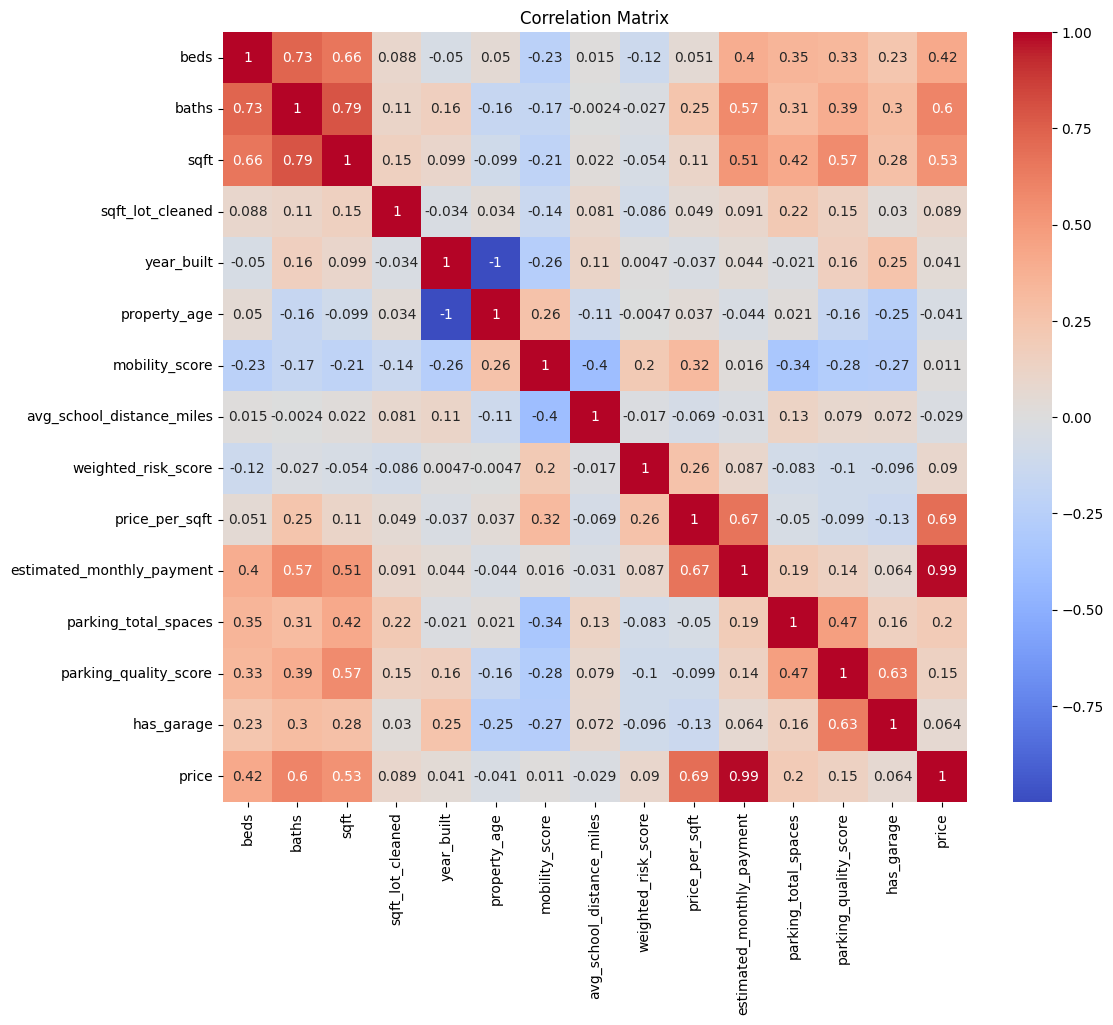

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df[numerical_cols + [target]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [268]:
df.to_csv('housing_data_after_feature_eng.csv')